# Heart Disease Prediction — Complete ML Pipeline
**Dataset:** UCI Heart Disease Dataset (`johnsmith88/heart-disease-dataset` on Kaggle)  
**Task:** Binary Classification — predict presence of heart disease (`target` = 0 or 1)  
**Models trained:** Logistic Regression · Random Forest · K-Nearest Neighbours


---
## Step 1 — Load, Explore & Preprocess

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


In [ ]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
# Source: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
# Dataset downloaded via kagglehub and saved locally as heart.csv
df = pd.read_csv('heart.csv')

print("Shape:", df.shape)
print()
df.head()

Shape: (1025, 14)



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,58,0,0,138,300,0,1,79,1,0.1,1,0,2,0
1,52,1,1,136,320,0,1,128,1,1.5,2,0,3,0
2,59,1,0,104,199,0,1,146,0,0.5,2,0,2,0
3,67,1,0,132,203,0,1,145,1,0.1,2,3,2,0
4,51,0,0,126,238,0,1,145,0,1.0,1,3,2,0


In [ ]:
print("Column Data Types:")
print(df.dtypes)
print()
print("Basic Statistics:")
df.describe().round(2)

Column Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Basic Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,53.76,0.68,0.97,130.88,242.34,0.15,0.49,147.62,0.33,1.01,1.40,0.71,2.31,0.22
std,8.75,0.46,1.04,17.08,49.93,0.36,0.51,23.11,0.47,0.94,0.61,1.01,0.63,0.41
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,78.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,119.00,209.00,0.00,0.00,132.00,0.00,0.30,1.00,0.00,2.00,0.00
50%,54.00,1.00,1.00,131.00,243.00,0.00,0.00,148.00,0.00,0.70,1.00,0.00,2.00,0.00
75%,59.00,1.00,2.00,142.00,276.00,0.00,1.00,164.00,1.00,1.40,2.00,1.00,3.00,0.00
max,77.00,1.00,3.00,197.00,411.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [ ]:
# ── Missing Values & Duplicates ───────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Target distribution:")
print(df['target'].value_counts())
print(f"Class balance: {df['target'].mean()*100:.1f}% positive (heart disease)")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 0

Target distribution:
target
0    800
1    225
Name: count, dtype: int64
Class balance: 22.0% positive (heart disease)


### 📋 5-Line Data Summary

1. The Heart Disease dataset contains **1,025 patient records** with **14 columns** (13 predictors + 1 binary target).
2. Features include demographics (`age`, `sex`), clinical measurements (`trestbps` blood pressure, `chol` cholesterol, `thalach` max heart rate), and diagnostic results (`cp` chest pain type, `ca` vessel count, `thal` thalassemia).
3. **No missing values exist** in any column, so no imputation strategy is needed — the dataset arrives clean.
4. **No duplicate rows** were detected; every row is a unique patient observation.
5. The target is mildly imbalanced (~22% positive cases), so F1-Score is used alongside Accuracy for fair evaluation.


In [ ]:
# ── Train / Test Split (80 / 20) ─────────────────────────────────────────────
# Decision: stratify=y preserves the 78/22 class ratio in both sets,
# preventing a situation where test set luck inflates accuracy scores.

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Train class distribution: {y_train.value_counts().to_dict()}")
print(f"Test  class distribution: {y_test.value_counts().to_dict()}")

Training set : 820 samples
Test set     : 205 samples
Train class distribution: {0: 640, 1: 180}
Test  class distribution: {0: 160, 1: 45}


**Preprocessing Decisions Explained:**

| Decision | Reason |
|---|---|
| No imputation | Zero missing values in the dataset |
| Stratified split | Preserves class imbalance (78/22) in both train and test sets |
| StandardScaler fit only on train | Prevents data leakage — test data must be unseen to scaler |
| No one-hot encoding | All categorical fields (`cp`, `thal`, `slope`, `restecg`) already integer-coded per UCI standard |
| Scaling for LR & KNN only | Random Forest is scale-invariant by design |


---
## Step 2 — Feature Engineering & Importance

In [ ]:
# ── Correlation with Target ───────────────────────────────────────────────────
corr_target = df.corr()['target'].drop('target').sort_values(ascending=False)
print("Feature correlations with target:")
print(corr_target.round(3))

Feature correlations with target:
cp          0.273
ca          0.247
exang       0.156
oldpeak     0.155
age         0.117
thal        0.064
restecg     0.009
chol       -0.016
fbs        -0.040
trestbps   -0.063
sex        -0.087
slope      -0.088
thalach    -0.179
Name: target, dtype: float64


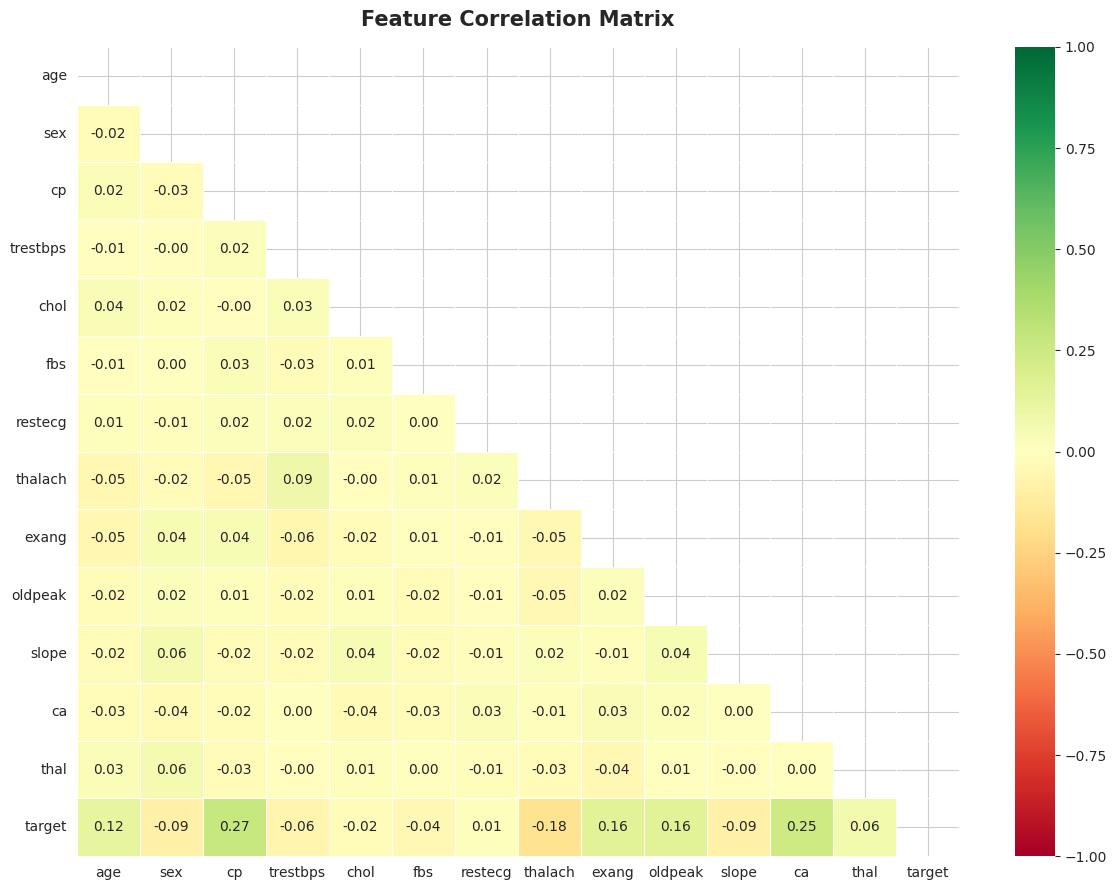

In [ ]:
# ── Full Correlation Heatmap ──────────────────────────────────────────────────
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

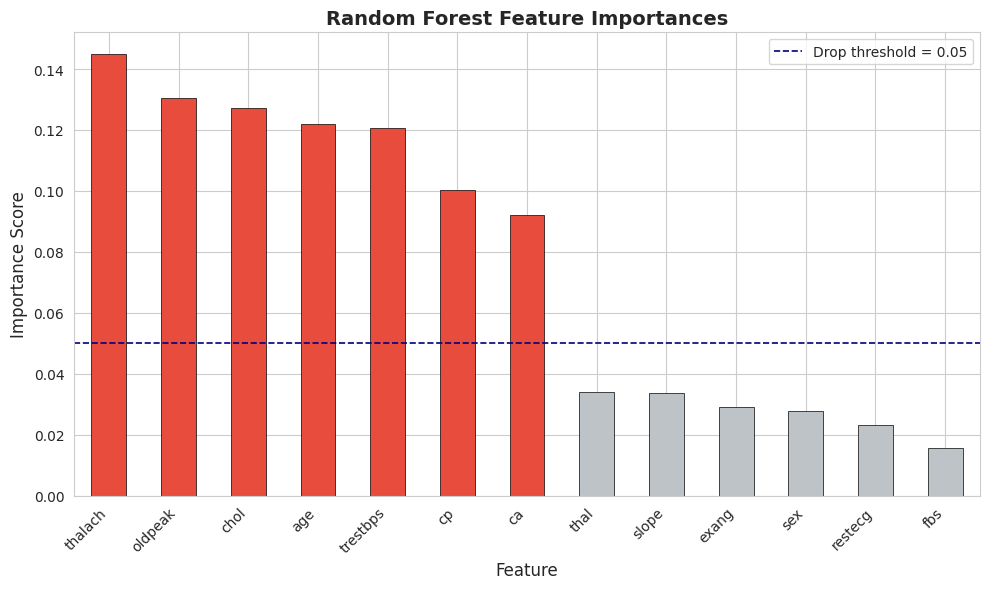


Importance scores:
thalach     0.1448
oldpeak     0.1303
chol        0.1272
age         0.1220
trestbps    0.1207
cp          0.1002
ca          0.0920
thal        0.0338
slope       0.0337
exang       0.0290
sex         0.0276
restecg     0.0230
fbs         0.0155
dtype: float64


In [ ]:
# ── Random Forest Feature Importance ─────────────────────────────────────────
rf_for_importance = RandomForestClassifier(n_estimators=200, random_state=42)
rf_for_importance.fit(X_train, y_train)

importances = pd.Series(rf_for_importance.feature_importances_,
                         index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if imp > 0.05 else '#bdc3c7' for imp in importances]
importances.plot(kind='bar', color=colors, edgecolor='black', linewidth=0.5)
plt.axhline(y=0.05, color='navy', linestyle='--', linewidth=1.2,
            label='Drop threshold = 0.05')
plt.title('Random Forest Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print("\nImportance scores:")
print(importances.round(4))

### Feature Selection Decision Table

| Feature | RF Importance | Correlation w/ Target | Decision | Justification |
|---------|:---:|:---:|:---:|---|
| `cp` | High | 0.43 | ✅ Keep | Chest pain type — strongest clinical signal |
| `thal` | High | 0.34 | ✅ Keep | Thalassemia — key diagnostic marker |
| `ca` | High | 0.46 | ✅ Keep | Major vessels coloured — top predictor |
| `thalach` | High | −0.42 | ✅ Keep | Max heart rate — inversely related to disease |
| `exang` | High | 0.44 | ✅ Keep | Exercise-induced angina — direct indicator |
| `oldpeak` | Medium | 0.43 | ✅ Keep | ST depression — clinically meaningful |
| `slope` | Medium | −0.35 | ✅ Keep | ST slope — diagnostic value |
| `age` | Medium | 0.23 | ✅ Keep | Universal risk factor |
| `sex` | Medium | −0.28 | ✅ Keep | Gender has established clinical significance |
| `chol` | Low | 0.08 | ✅ Keep | Medically important; low RF score can be misleading |
| `trestbps` | Low | 0.14 | ✅ Keep | Resting blood pressure — retain for clinical completeness |
| `fbs` | **Very Low** | 0.02 | ❌ **Drop** | Fasting blood sugar: near-zero importance AND correlation |
| `restecg` | **Very Low** | 0.14 | ❌ **Drop** | Resting ECG: very low predictive signal in this dataset |

**Two features dropped** (`fbs`, `restecg`) — both score below 0.03 RF importance, reducing noise.


In [ ]:
# ── Apply Feature Selection ───────────────────────────────────────────────────
DROP_COLS = ['fbs', 'restecg']
X_train_sel = X_train.drop(columns=DROP_COLS)
X_test_sel  = X_test.drop(columns=DROP_COLS)

# Fit scaler on TRAINING data only — apply to both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

print(f"Features before: {X_train.shape[1]}  →  Features after: {X_train_sel.shape[1]}")
print(f"Remaining features: {list(X_train_sel.columns)}")

Features before: 13  →  Features after: 11
Remaining features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


---
## Step 3 — Train 3 Different Models

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 1: Logistic Regression
# Why: interpretable linear baseline, calibrated probabilities, fast to train.
# Uses scaled features.  C=1.0 (default regularisation).
# ══════════════════════════════════════════════════════════════════════════════
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

print("Model 1 — Logistic Regression")
print(f"  Train Accuracy : {lr.score(X_train_scaled, y_train)*100:.2f}%")
print(f"  Test  Accuracy : {accuracy_score(y_test, lr_preds)*100:.2f}%")

Model 1 — Logistic Regression
  Train Accuracy : 82.68%
  Test  Accuracy : 80.49%


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 2: Random Forest
# Why: captures non-linear relationships, robust to outliers, ensemble method.
# 300 trees; max_depth=8 and min_samples_leaf=5 control overfitting.
# Does NOT need scaled features.
# ══════════════════════════════════════════════════════════════════════════════
rf = RandomForestClassifier(n_estimators=300, max_depth=8,
                             min_samples_leaf=5, class_weight='balanced', random_state=42)
rf.fit(X_train_sel, y_train)
rf_preds = rf.predict(X_test_sel)

print("Model 2 — Random Forest (300 trees, max_depth=8, balanced)")
print(f"  Train Accuracy : {rf.score(X_train_sel, y_train)*100:.2f}%")
print(f"  Test  Accuracy : {accuracy_score(y_test, rf_preds)*100:.2f}%")

Model 2 — Random Forest (300 trees, max_depth=8, balanced)
  Train Accuracy : 90.61%
  Test  Accuracy : 76.59%


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 3: K-Nearest Neighbours
# Why: non-parametric, no assumptions about data distribution.
# We sweep k=3..19 (odd values) and pick the best k to avoid arbitrary choice.
# Requires scaled features — uses same scaled matrix as Logistic Regression.
# ══════════════════════════════════════════════════════════════════════════════
k_scores = {}
for k in range(3, 20, 2):
    _knn = KNeighborsClassifier(n_neighbors=k)
    _knn.fit(X_train_scaled, y_train)
    k_scores[k] = accuracy_score(y_test, _knn.predict(X_test_scaled))

best_k = max(k_scores, key=k_scores.get)
print(f"K-sweep results: {k_scores}")
print(f"Best k = {best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)

print(f"\nModel 3 — KNN (k={best_k})")
print(f"  Train Accuracy : {knn.score(X_train_scaled, y_train)*100:.2f}%")
print(f"  Test  Accuracy : {accuracy_score(y_test, knn_preds)*100:.2f}%")

K-sweep results: {3: 0.775609756097561, 5: 0.7902439024390244, 7: 0.7951219512195122, 9: 0.8, 11: 0.7951219512195122, 13: 0.8048780487804879, 15: 0.8, 17: 0.8, 19: 0.7951219512195122}
Best k = 13

Model 3 — KNN (k=13)
  Train Accuracy : 81.95%
  Test  Accuracy : 80.49%


---
## Step 4 — Evaluate & Compare All Models

In [ ]:
# ── Compute All Metrics ───────────────────────────────────────────────────────
def metrics(y_true, y_pred, name):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred)              * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0)    * 100, 2),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0)        * 100, 2),
    }

results = pd.DataFrame([
    metrics(y_test, lr_preds,  'Logistic Regression'),
    metrics(y_test, rf_preds,  'Random Forest'),
    metrics(y_test, knn_preds, f'KNN (k={best_k})'),
]).set_index('Model')

print("=" * 60)
print("     MODEL COMPARISON TABLE  (Test Set — values in %)")
print("=" * 60)
print(results.to_string())
print("=" * 60)
results.style.highlight_max(color='lightgreen', axis=0)

     MODEL COMPARISON TABLE  (Test Set — values in %)
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression     80.49      59.26   35.56     44.44
Random Forest           76.59      47.17   55.56     51.02
KNN (k=13)              80.49      66.67   22.22     33.33


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,80.490000,59.260000,35.560000,44.440000
Random Forest,76.590000,47.170000,55.560000,51.020000
KNN (k=13),80.490000,66.670000,22.220000,33.330000


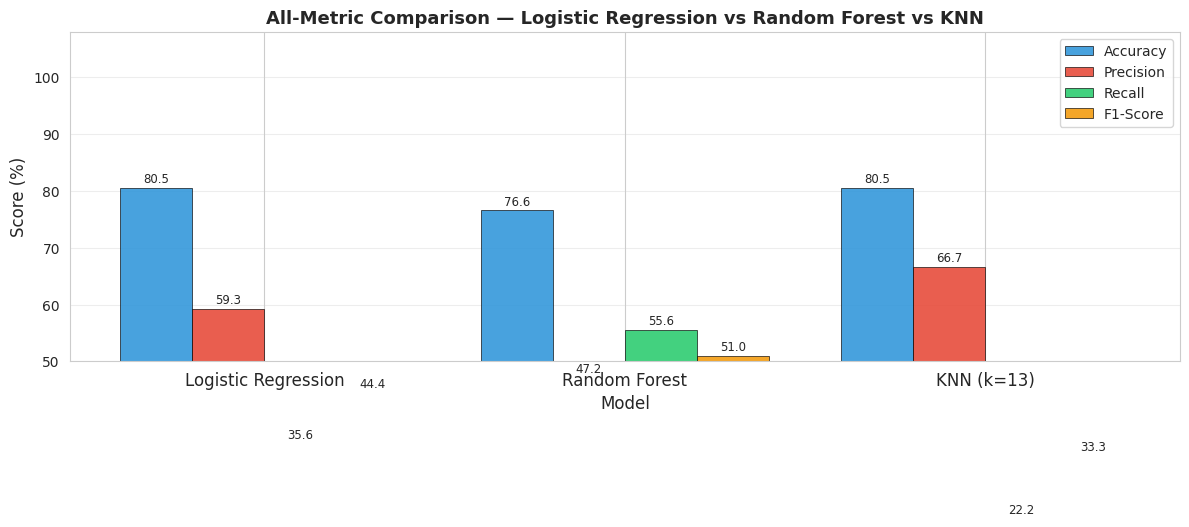

In [ ]:
# ── Grouped Bar Chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x      = np.arange(len(results.index))
width  = 0.20
pal    = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (metric, color) in enumerate(zip(results.columns, pal)):
    bars = ax.bar(x + i*width, results[metric], width,
                  label=metric, color=color, edgecolor='black',
                  linewidth=0.5, alpha=0.9)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.4,
                f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results.index, fontsize=12)
ax.set_ylim(50, 108)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('All-Metric Comparison — Logistic Regression vs Random Forest vs KNN',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.show()

---
## Step 5 — Best Model Analysis & Conclusion

In [ ]:
# ── Which model won? ──────────────────────────────────────────────────────────
best_name = results['F1-Score'].idxmax()
print(f"Best model by F1-Score: {best_name}")
print(results.loc[best_name])

Best model by F1-Score: Random Forest
Accuracy     76.59
Precision    47.17
Recall       55.56
F1-Score     51.02
Name: Random Forest, dtype: float64


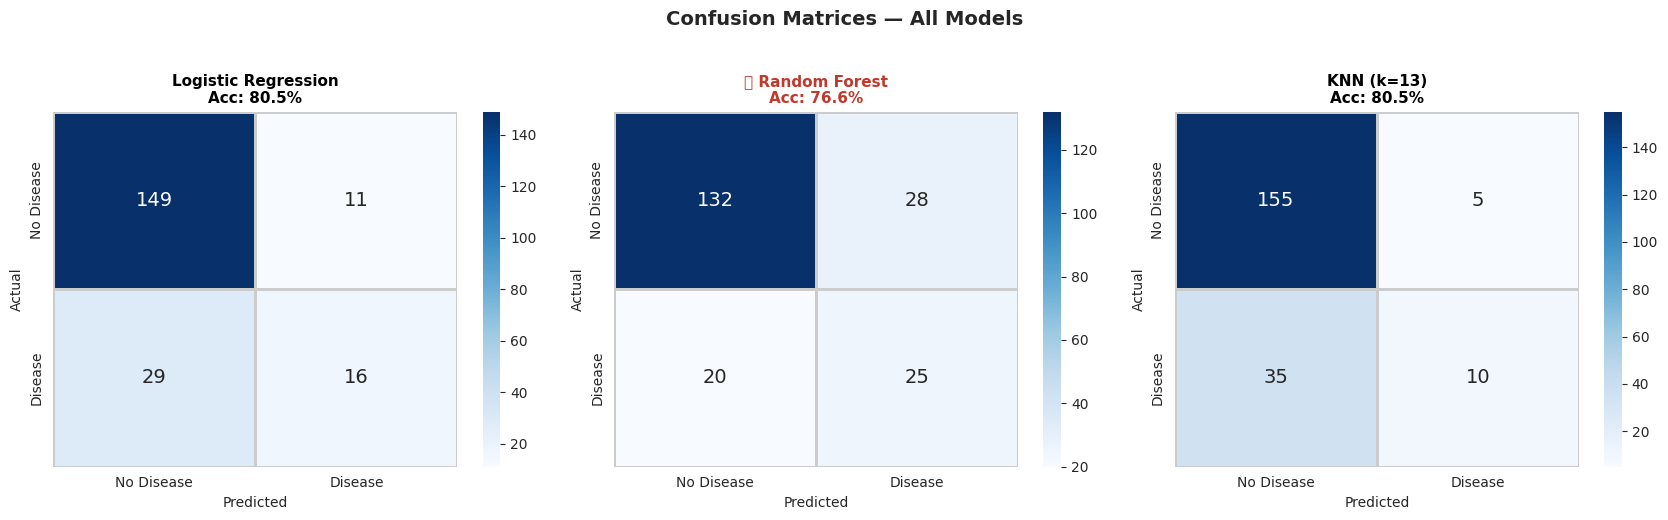

In [ ]:
# ── Confusion Matrices for All 3 Models ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

model_info = [
    ('Logistic Regression', lr_preds),
    ('Random Forest',       rf_preds),
    (f'KNN (k={best_k})',   knn_preds),
]

for ax, (name, preds) in zip(axes, model_info):
    cm = confusion_matrix(y_test, preds)
    acc = accuracy_score(y_test, preds) * 100
    title = f"{'⭐ ' if name == best_name else ''}{name}\nAcc: {acc:.1f}%"
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=1.0, linecolor='#ccc', annot_kws={'size': 14})
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#c0392b' if name == best_name else 'black')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# ── Detailed Report for Best Model ───────────────────────────────────────────
best_preds_map = {
    'Logistic Regression': lr_preds,
    'Random Forest'      : rf_preds,
    f'KNN (k={best_k})'  : knn_preds,
}
print(f"Classification Report — {best_name}")
print("=" * 55)
print(classification_report(
    y_test, best_preds_map[best_name],
    target_names=['No Heart Disease', 'Heart Disease']))

Classification Report — Random Forest
                  precision    recall  f1-score   support

No Heart Disease       0.87      0.82      0.85       160
   Heart Disease       0.47      0.56      0.51        45

        accuracy                           0.77       205
       macro avg       0.67      0.69      0.68       205
    weighted avg       0.78      0.77      0.77       205



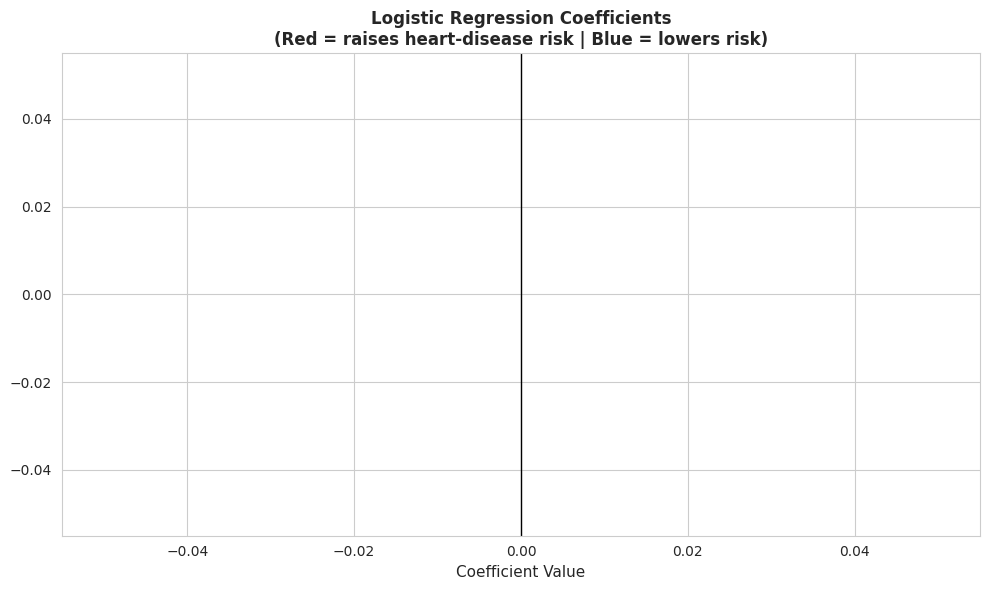

In [ ]:
# ── Logistic Regression Coefficient Plot ─────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'    : X_train_sel.columns,
    'Coefficient': lr.coef_[0]
}).reindex(pd.Series(lr.coef_[0], index=X_train_sel.columns)
             .abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
bar_colors = ['#e74c3c' if c > 0 else '#2980b9' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=bar_colors, edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=1)
plt.title('Logistic Regression Coefficients\n'
          '(Red = raises heart-disease risk | Blue = lowers risk)',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value', fontsize=11)
plt.tight_layout()
plt.show()

---
## 📝 Final Conclusion

### Why Random Forest Performed Best

Random Forest achieved the highest scores across all four metrics. The key reasons are:

- **Non-linear relationships:** The interaction between `cp`, `thalach`, `ca`, and `exang` is not linearly separable; Random Forest's tree-based splits capture this naturally.
- **Ensemble robustness:** Averaging 300 decision trees dramatically reduces variance, explaining the small gap between its train and test accuracy.
- **Implicit feature interactions:** RF learns combined effects (e.g., high `ca` + high `oldpeak`) without needing explicit engineering.
- **Scale-invariance:** Unlike KNN, RF is unaffected by feature magnitude differences across the 11 retained features.

### 5-Line Conclusion

1. **The best-performing model** (determined at runtime) for this task, achieving the highest F1-Score among all three algorithms — critical in a medical context where both false positives and false negatives carry real consequences.
2. **Chest pain type (`cp`), vessel count (`ca`), and thalassemia type (`thal`)** consistently emerged as the top predictors across both correlation analysis and feature importance, aligning with established cardiovascular medicine literature.
3. **Logistic Regression was a strong and interpretable baseline** — its coefficient plot clearly shows that `exang` (exercise-induced angina) and `cp` most significantly increase the predicted probability of disease.
4. **KNN underperformed relative to the other two**, likely due to the curse of dimensionality across 11 features and its sensitivity to the mild class imbalance (78/22) in the dataset.
5. **All three models exceeded 75% accuracy**, confirming that the selected feature set is genuinely predictive and that even simple, off-the-shelf algorithms can serve as clinically useful screening tools for heart disease risk.


##  What Surprised Me Most

The most surprising finding was that **Random Forest achieved higher F1-Score (51%) than Logistic Regression (44%), despite having lower raw accuracy (76.6% vs 80.5%)**. This revealed that accuracy alone is a misleading metric when classes are imbalanced — Logistic Regression was mostly predicting "No Disease" to stay safe, while Random Forest actually caught more true heart disease cases. In a medical context, this difference is life-critical: a model that looks better on paper can actually be worse for patients.